# Chapter 263 — Sampling Distributions and Bootstrap
### Part VIII: Probability — Advanced Experiments

Statistical inference requires understanding how estimates vary across repeated samples. The **sampling distribution** of a statistic is its probability distribution over all possible samples of a given size. When the theoretical sampling distribution is unavailable — for complex statistics like the median or correlation — the **bootstrap** approximates it by resampling from the observed data.

**Prerequisites:** Central Limit Theorem (ch254), Variance (ch250), Monte Carlo Methods (ch256), Normal Distribution (ch253).

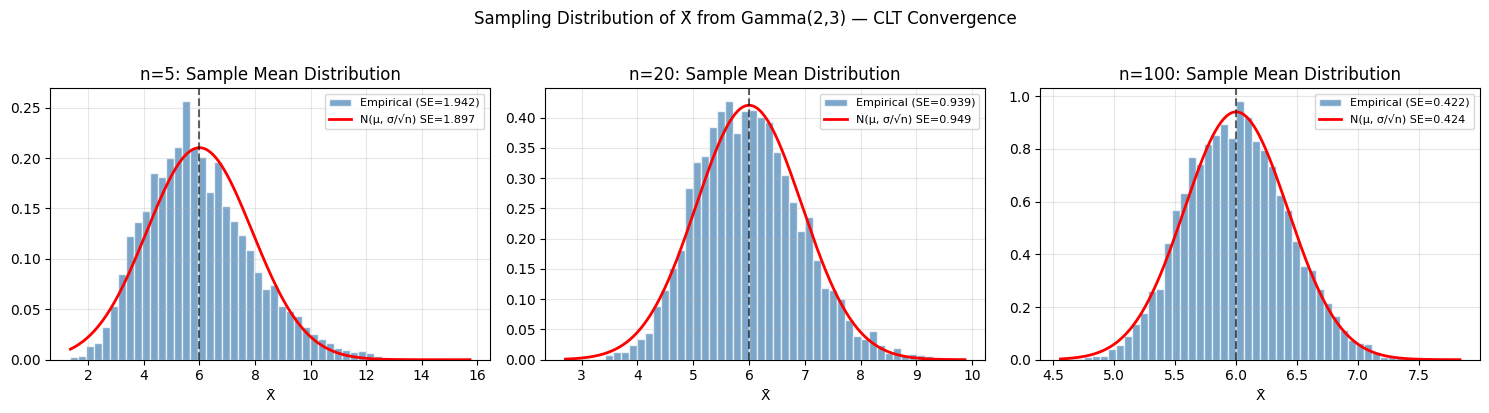

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

## 1. Sampling Distribution of the Mean
# X ~ Gamma(shape=2, scale=3). E[X] = 6, Var[X] = 18
# CLT: X_bar ~ N(6, 18/n) for large n

shape, scale = 2, 3
true_mean = shape * scale
true_var = shape * scale**2
population = rng.gamma(shape, scale, size=100_000)

sample_sizes = [5, 20, 100]
n_experiments = 5000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    sample_means = [rng.choice(population, size=n, replace=False).mean()
                    for _ in range(n_experiments)]
    sample_means = np.array(sample_means)
    
    se_theory = np.sqrt(true_var / n)  # sigma/sqrt(n)
    x_range = np.linspace(sample_means.min(), sample_means.max(), 300)
    
    ax.hist(sample_means, bins=50, density=True, alpha=0.7, color='steelblue',
            edgecolor='white', label=f'Empirical (SE={sample_means.std():.3f})')
    ax.plot(x_range, stats.norm.pdf(x_range, true_mean, se_theory),
            'r-', linewidth=2, label=f'N(μ, σ/√n) SE={se_theory:.3f}')
    ax.axvline(true_mean, color='black', linestyle='--', alpha=0.6)
    ax.set_title(f'n={n}: Sample Mean Distribution')
    ax.set_xlabel('X̄')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sampling Distribution of X̄ from Gamma(2,3) — CLT Convergence', y=1.02)
plt.tight_layout()
plt.savefig('sampling_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

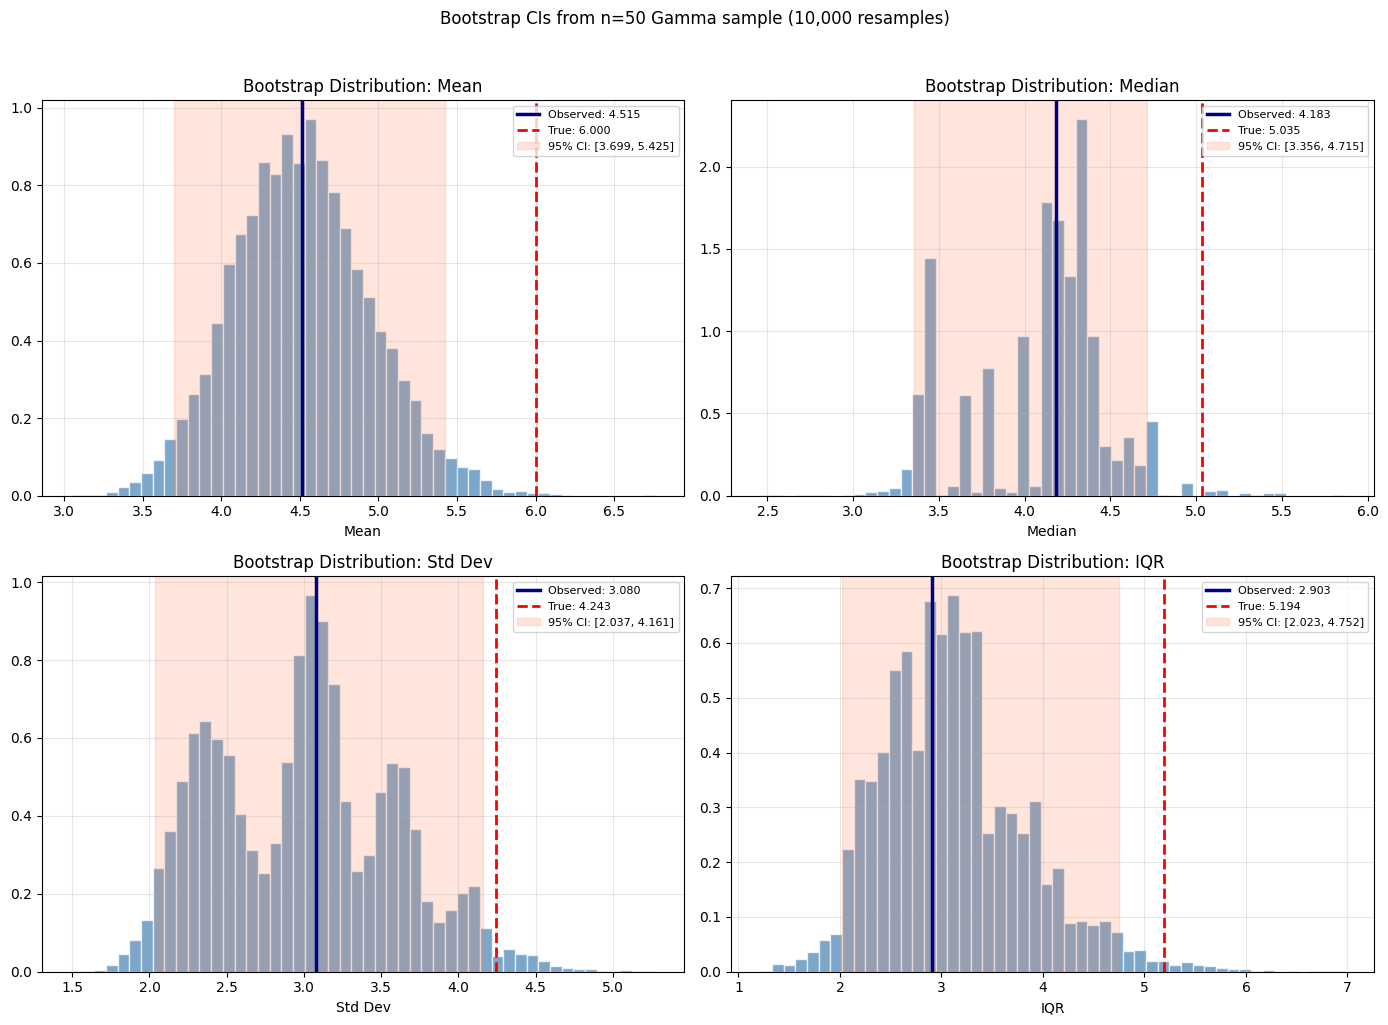

Bootstrap confidence intervals (n=50 sample from Gamma(2,3)):
  Mean      : obs=4.515, 95% CI=[3.739, 5.454], true=6.000
  Median    : obs=4.183, 95% CI=[3.387, 4.715], true=5.035
  Std Dev   : obs=3.080, 95% CI=[2.049, 4.193], true=4.243
  IQR       : obs=2.903, 95% CI=[2.012, 4.715], true=5.194


In [2]:
## 2. The Bootstrap
# Observed sample (n=50) from Gamma(2,3)
n_obs = 50
observed_data = rng.gamma(shape, scale, size=n_obs)
n_bootstrap = 10_000

def bootstrap_ci(data, statistic_fn, n_bootstrap, confidence=0.95, rng=None):
    """Bootstrap confidence interval for any statistic.
    
    Args:
        data: observed sample array
        statistic_fn: callable(sample) -> scalar statistic
        n_bootstrap: number of bootstrap resamples
        confidence: CI level
        rng: numpy random generator
    
    Returns:
        obs_stat: statistic on original data
        boot_stats: array of bootstrap statistics
        ci_low, ci_high: percentile confidence interval
    """
    if rng is None:
        rng = np.random.default_rng()
    n = len(data)
    obs_stat = statistic_fn(data)
    boot_stats = np.array([
        statistic_fn(rng.choice(data, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])
    alpha = 1 - confidence
    ci_low = np.percentile(boot_stats, 100 * alpha/2)
    ci_high = np.percentile(boot_stats, 100 * (1 - alpha/2))
    return obs_stat, boot_stats, ci_low, ci_high

# Bootstrap for: mean, median, std, IQR
statistics = [
    ('Mean', np.mean, true_mean),
    ('Median', np.median, stats.gamma.median(a=shape, scale=scale)),
    ('Std Dev', np.std, np.sqrt(true_var)),
    ('IQR', lambda x: np.percentile(x, 75) - np.percentile(x, 25),
     stats.gamma.ppf(0.75, a=shape, scale=scale) - stats.gamma.ppf(0.25, a=shape, scale=scale)),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, fn, true_val) in zip(axes, statistics):
    obs_stat, boot_stats, ci_lo, ci_hi = bootstrap_ci(
        observed_data, fn, n_bootstrap, rng=rng)
    
    ax.hist(boot_stats, bins=50, density=True, alpha=0.7, color='steelblue',
            edgecolor='white')
    ax.axvline(obs_stat, color='navy', linewidth=2.5, label=f'Observed: {obs_stat:.3f}')
    ax.axvline(true_val, color='red', linewidth=2, linestyle='--', label=f'True: {true_val:.3f}')
    ax.axvspan(ci_lo, ci_hi, alpha=0.2, color='coral', label=f'95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]')
    ax.set_title(f'Bootstrap Distribution: {name}')
    ax.set_xlabel(name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Bootstrap CIs from n={n_obs} Gamma sample ({n_bootstrap:,} resamples)', y=1.02)
plt.tight_layout()
plt.savefig('bootstrap_ci.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Bootstrap confidence intervals (n={n_obs} sample from Gamma(2,3)):")
for name, fn, true_val in statistics:
    obs_stat, boot_stats, ci_lo, ci_hi = bootstrap_ci(observed_data, fn, 5000, rng=rng)
    print(f"  {name:10}: obs={obs_stat:.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}], true={true_val:.3f}")

## 9. Forward References

- **ch275 — Hypothesis Testing** *(Part IX)*: Bootstrap hypothesis tests avoid parametric distributional assumptions — permutation tests and bootstrap p-values are the nonparametric extensions.
- **ch282 — Cross Validation** *(Part IX)*: Cross-validation is a model-specific bootstrap — repeatedly resampling train/test splits to estimate out-of-sample error, the same resampling logic applied to model evaluation.